In [79]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
import matplotlib.pyplot as plt

In [2]:
tf.config.threading.set_intra_op_parallelism_threads(12)
tf.config.threading.set_inter_op_parallelism_threads(12)

print("Threads configured")

Threads configured


In [93]:
df = pd.read_csv("../../../datasets/Churn_Modelling.csv")

In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [95]:
df.drop(columns=['RowNumber', 'CustomerId'], inplace=True)

In [96]:
df.head()

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [97]:
# df = pd.get_dummies(df, columns=['Surname', 'Geography', 'Gender'])

le = LabelEncoder()

df['Surname'] = le.fit_transform(df['Surname'])
df['Geography'] = le.fit_transform(df['Geography'])
df['Gender'] = le.fit_transform(df['Gender'])

In [98]:
df.head()

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1115,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,1177,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,2040,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,289,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,1822,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [99]:
x = df.drop(columns=['Exited'])
y = df['Exited']

In [100]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

In [101]:
scaler = StandardScaler()
x_train_scale = scaler.fit_transform(x_train)
x_test_scale = scaler.transform(x_test)

In [107]:
model = Sequential()

model.add(Input(shape=(x_train_scale.shape[1], )))
model.add(Dense(8, activation='relu'))
# model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [108]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 8)              │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105 (420.00 B)

 Trainable params: 105 (420.00 B)

 Non-trainable params: 0 (0.00 B)

In [109]:
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [110]:
history = model.fit(x=x_train_scale, y=y_train, epochs=100, batch_size=256, validation_split=0.2)

Epoch 1/100


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7356 - loss: 0.5842 - val_accuracy: 0.7556 - val_loss: 0.5635
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7597 - loss: 0.5568 - val_accuracy: 0.7731 - val_loss: 0.5423
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7770 - loss: 0.5348 - val_accuracy: 0.7806 - val_loss: 0.5251
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7845 - loss: 0.5172 - val_accuracy: 0.7850 - val_loss: 0.5105
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7897 - loss: 0.5029 - val_accuracy: 0.7919 - val_loss: 0.4980
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7912 - loss: 0.4908 - val_accuracy: 0.7950 - val_loss: 0.4880
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7933 - loss: 0.4809 - val_accuracy: 0.7950 - val_loss: 0.4793
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7947 - loss: 0.4727 - val_accuracy: 0.7919 - val_loss: 0.

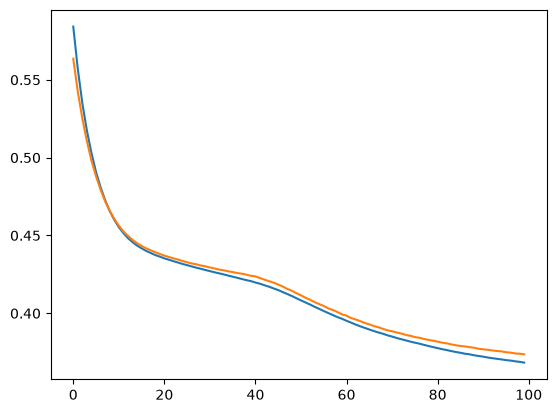

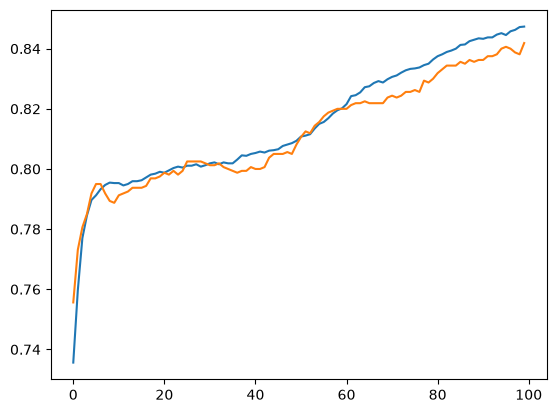

In [111]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

In [21]:
model.layers[0].get_weights()

[array([[-0.10469976, -0.43875223, -0.38323802, ...,  0.21016493,
         -0.35746473,  0.28320518],
        [-0.09334213, -0.8381729 ,  0.40245816, ..., -0.17897505,
          0.10154495, -0.03789362],
        [ 0.2322501 , -0.02631914,  0.0241443 , ..., -0.50925285,
          0.05786886, -0.18776755],
        ...,
        [ 0.2191725 , -0.42261383, -0.8455696 , ..., -0.80230784,
          0.19322634,  0.06885885],
        [-0.22560762, -0.53126   , -0.44812223, ...,  0.00965682,
          0.10977705,  0.30657047],
        [ 0.20963563,  0.5152748 ,  0.49700287, ..., -0.06383849,
         -0.08419861, -0.27525127]], shape=(2945, 32), dtype=float32),
 array([ 0.02732873,  0.02338191, -0.13166699,  0.02199155, -0.09369728,
        -0.09863391, -0.01981501,  0.03862572,  0.05134922, -0.00205285,
        -0.13279149,  0.07537928,  0.06416601, -0.00822099,  0.00071405,
        -0.06225327,  0.04138045, -0.06372683, -0.07154167,  0.05121697,
         0.0477047 ,  0.05224255, -0.03142269, -

In [22]:
model.layers[1].get_weights()

[array([[ 0.38853887, -0.36571312, -0.13798839, ...,  0.20522633,
         -0.01337081, -0.32617864],
        [ 0.45682144, -0.54562473, -0.18721077, ...,  0.38526413,
          0.6181123 , -0.5628266 ],
        [-0.14098543,  0.33138102,  0.248357  , ..., -0.10199611,
         -0.42866847,  0.36456564],
        ...,
        [ 0.3881651 , -0.40357497, -0.3504325 , ...,  0.01189076,
          0.4144307 , -0.57416666],
        [-0.01597115, -0.25739643, -0.3764719 , ...,  0.39970708,
          0.48323822, -0.46731648],
        [-0.29227087, -0.1010095 ,  0.19670577, ..., -0.24403377,
          0.07050072, -0.04248856]], shape=(32, 64), dtype=float32),
 array([-1.83640588e-02, -1.72212087e-02,  1.15141915e-02, -3.97560075e-02,
        -7.07571860e-03, -7.25626647e-02, -5.31366467e-02,  1.26293264e-02,
        -4.63079847e-03, -8.05182941e-03,  3.93831097e-02, -4.73077744e-02,
        -5.68619333e-02, -5.25735021e-02, -3.61267291e-02, -8.46186467e-03,
         2.95436177e-02, -9.77120697e-

In [112]:
y_pred = np.where(model.predict(x=x_test_scale) > 0.5, 1 , 0)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [113]:
mean_absolute_error(y_test, y_pred)

0.159

In [114]:
mean_squared_error(y_test, y_pred)

0.159

In [115]:
y_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(2000, 1))

In [116]:
r2_score(y_test, y_pred)

0.0331040249325375

In [117]:
accuracy_score(y_test, y_pred)

0.841